# Data Science I
<div style="position: relative;">
    <div style="position: absolute; top: -60px; right: 10px; padding: 5px; background-color: transparent; font-size: 20px; text-align: right;">
        <span>Version: October 10, 2025</span>
    </div>
</div>

## Project Report: Predicting Energy Prices
<span style="font-weight: bold; text-decoration: underline;">Submission Deadline: January 25 2026, 21:00 UTC</span>
    
**University of Oldenburg**<br/>
**Winter 2025/2026**<br/>
**Instructors**: [Jannik Schröder](https://uol.de/team-data/jannik-schroeder), [Wolfram "Wolle" Wingerath](https://uol.de/wolle)

<span style="font-weight: bold; ">Submitted by: <span style="color: red;">Kryvtsova Vlada, Winkler David, Brüning Menko</span>

---

# Introduction
Electricity markets require generators, traders, and large consumers to plan production and consumption ahead of time. In Europe, one of the most important reference markets is the **day-ahead market**, where participants submit bids and offers for each delivery hour of the next day. The market is then cleared so that supply meets demand, resulting in a separate hourly price (€/MWh) for each hour of the following day. These prices can vary strongly due to demand patterns, renewable generation, fuel costs, and seasonal effects, and they may even become negative during periods of high renewable supply and low demand.

The goal of this project is to forecast Germany’s day-ahead electricity prices for a specific target date, **January 27, 2026**, using historical data from 2018–2025. We frame the task as an **hourly supervised forecasting problem** with the target variable being the price for delivery hour *t*. As explanatory variables, we use a compact set of drivers available in our dataset. Some of them are the previous day’s price, forecasts for load, wind and solar generation, calendar variables.

To assess the value of increasing model complexity, we implement and compare four levels of models: 
*  **Level 0**: naive persistence baseline (“tomorrow equals yesterday”)
*  **Level 1**: seasonal time-series model (SARIMA)
*  **Level 2**: linear regression model using multiple features
*  **Level 3**: machine-learning model (XGBoost).

Models are evaluated with time-aware splits and standard error metrics to ensure a fair comparison without information leakage. The report presents the dataset, modeling choices, evaluation methodology, and results, and concludes with limitations and potential improvements for future work.

<a id="data-preprocessing"></a>
# Part 1. Gathering Data Sources

## 1.1 Time span
The dataset used in this project combines several time series that are relevant for explaining and forecasting German day-ahead electricity prices. The sourced data covers the period **from October 1, 2018** to **January 25, 2025** with an hourly resolution. The starting point is chosen as such, because the bidding zone DE/AT/LU split into DE/LU and AT became valid at that point. In this project, DE/LU is being used. Furthermore, this time span is sufficiently long to support robust model training and evaluation, while capturing both structural trends and exceptional market conditions. In particular, the price spike in 2022 visible in the figure below reflects a short-lived geopolitical shock, triggered by Russia’s reduction of natural gas supplies to Europe.\
\
Including such extreme but historically significant events allows the model to learn how electricity prices respond to rare disruptions. This reduces the risk of misinterpreting these dynamics as random noise and improves generalization under stress scenarios.\
\
In addition, the selected time period covers several consecutive years of relatively stable market operation, which delievers a robust baseline for learning persistent and systematic relationships in day-ahead electricity pricing.

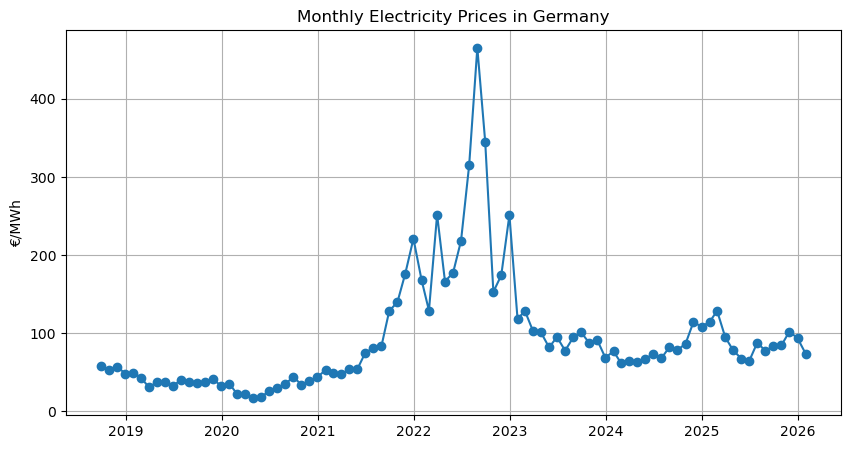

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd

electricity_prices = pd.read_csv("entsoe_forecasts.csv")
electricity_prices["Date"] = pd.to_datetime(
    electricity_prices["Date"],
    utc=True
)

electricity_prices = electricity_prices.set_index("Date").sort_index()

monthly_prices = electricity_prices["Price_DayAhead"].resample("ME").mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_prices, marker='o')
plt.title("Monthly Electricity Prices in Germany")
plt.ylabel("€/MWh")
plt.grid(True)
plt.show()

## 1.2 Data Parameters & Sources

### 1.2.1 ENTSO-E Transparency Platform

The primary data source for electricity market variables is the ENTSO-E Transparency Platform ([transparency.entsoe.eu](https://transparency.entsoe.eu)), the official publication platform of the European Network of Transmission System Operators for Electricity. Data was accessed via the `entsoe-py` Python library.

The day-ahead prices originate from the Single Day-Ahead Coupling (SDAC), a pan-European mechanism that couples national wholesale electricity markets. The market clearing occurs daily around 12:00 CET, determining prices for each delivery hour of the following day.

| Column | Description | Unit | Source | Role |
|--------|-------------|------|--------|------|
| Date | Timestamp in hourly resolution (UTC) | - | - | Index |
| Price_DayAhead | Day-ahead electricity market clearing price | €/MWh | `query_day_ahead_prices` | Target (y) |
| Load_Forecast | Day-ahead forecasted total electricity demand | MW | `query_load_forecast` | Feature (X) |
| Solar | Day-ahead forecasted solar generation | MW | `query_wind_and_solar_forecast` | Feature (X) |
| Wind_Offshore | Day-ahead forecasted offshore wind generation | MW | `query_wind_and_solar_forecast` | Feature (X) |
| Wind_Onshore | Day-ahead forecasted onshore wind generation | MW | `query_wind_and_solar_forecast` | Feature (X) |

### 1.2.2 Open-Meteo Weather API

To capture weather-driven effects on electricity demand and renewable generation, we sourced hourly weather forecast data from the Open-Meteo API ([open-meteo.com](https://open-meteo.com)), an open-source weather API. We used the Historical Forecast API (`historical-forecast-api.open-meteo.com`) for past data and the Forecast API (`api.open-meteo.com`) for current predictions. Weather data was aggregated from six major German cities: Hamburg, Berlin, Leipzig, Frankfurt, Cologne, and Munich.

| Column | Description | Unit | API Parameter | Role |
|--------|-------------|------|---------------|------|
| timestamp | Hourly timestamp (Europe/Berlin → UTC) | - | - | Index |
| Weather_Temp_Forecast | Mean air temperature at 2m across six cities | °C | `temperature_2m` | Feature (X) |
| Weather_Wind_Forecast | Mean wind speed at 100m across six cities | m/s | `windspeed_100m` | Feature (X) |
| Weather_Solar_Forecast | Mean global horizontal irradiance across six cities | W/m² | `shortwave_radiation` | Feature (X) |

## 1.3 Data Cleaning 

### 1.3.1 Unification

Because Europe’s coupled day-ahead electricity market switched to 15-minute pricing for delivery starting 1 October 2025, ENTSO-E’s published day-ahead series follows that market design. To avoid mixed-frequency time series (hourly, then quarter-hourly), the first step is to unify them by converting everything to hourly.

In [2]:
# compute time differences between consecutive timestamps
time_diffs = electricity_prices.index.to_series().diff()

hourly_step = pd.Timedelta(hours=1)

# find first timestamp where the step is smaller than 1 hour
change_point = time_diffs[time_diffs < hourly_step].index.min()

df_hourly = electricity_prices.resample("h").mean()

To make working with data easier, we are combinig the electricity and weather data in one data set. The goal is to achieve an hour-aligned merge. However, the timestamps in weather data are time-naive, while those in electricity data are time-aware. So, we decided to join the data sets using UTC in both of them.

In [3]:
weather = pd.read_csv(
    "weather_forecasts_aggregated.csv",
    index_col=0,
    parse_dates=True
)

# convert weather data to UTC
df_weather_hourly = (
    weather
    .tz_localize("Europe/Berlin", nonexistent="shift_forward", ambiguous=False)
    .tz_convert("UTC")
)

# unify electricity & weather based on UTC
df = df_hourly.join(df_weather_hourly, how="inner")
df.head()

,Price_DayAhead,Load_Forecast,Solar,Wind_Offshore,Wind_Onshore,Weather_Temp_Forecast,Weather_Wind_Forecast,Weather_Solar_Forecast
2018-09-30 22:00:00+00:00,59.53,NaN,0.0,1635.76,4287.76,10.4,23.7,0.0
2018-09-30 23:00:00+00:00,56.10,NaN,0.0,1602.39,4148.19,11.0,21.1,0.0
2018-10-01 00:00:00+00:00,51.41,42695.57,0.0,1736.57,4004.51,9.9,16.6,0.0
2018-10-01 01:00:00+00:00,47.38,42746.84,0.0,1792.04,4333.29,10.4,20.0,0.0
2018-10-01 02:00:00+00:00,47.59,44038.05,0.0,2059.44,4611.93,10.4,20.9,0.0


### 1.3.2 Cleaning
Next we will identify the missing values.

In [4]:
print(df.isna().sum())

Price_DayAhead              7
Load_Forecast             904
Solar                      16
Wind_Offshore              13
Wind_Onshore               16
Weather_Temp_Forecast       0
Weather_Wind_Forecast       0
Weather_Solar_Forecast      0
dtype: int64


We can see that the data for **forecasted demand** is missing the most. One of the best ways to handle missing values in time series is **time-series interpolation**. It is a method to estimate missing values using nearby known values. It assumes the variable changes smoothly over time and estimates missing points from neighboring timestamps, making it suitable for short gaps in continuous, ordered data. That being said, we firstly need to examine *Load_Forecast* to see whether it follows a particular trend.

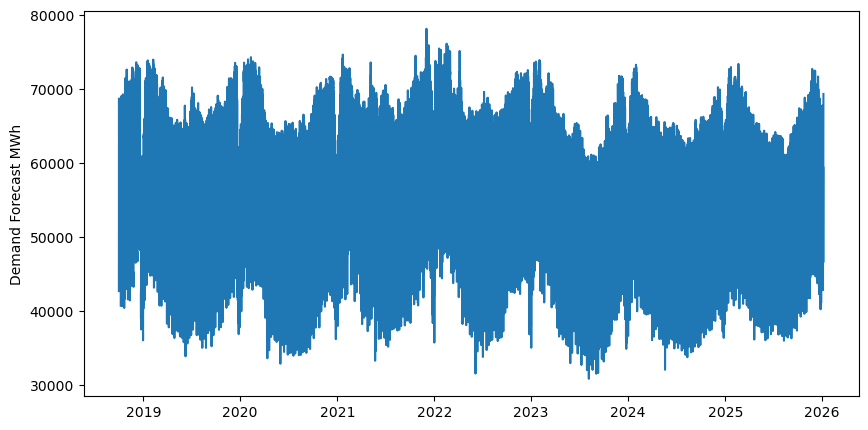

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Load_Forecast"])
plt.ylabel("Demand Forecast MWh")
plt.show()

**Conclusion:** There is a strong seasonal trend. Fluctuations are smooth and continious. Therefore, for this case time-based interpolation is a good choice to handle missing values.

In [6]:
# apply time-based interpolation
df["Load_Forecast"] = (
    df["Load_Forecast"]
    .interpolate(method="time")
)
df.head()

,Price_DayAhead,Load_Forecast,Solar,Wind_Offshore,Wind_Onshore,Weather_Temp_Forecast,Weather_Wind_Forecast,Weather_Solar_Forecast
2018-09-30 22:00:00+00:00,59.53,NaN,0.0,1635.76,4287.76,10.4,23.7,0.0
2018-09-30 23:00:00+00:00,56.10,NaN,0.0,1602.39,4148.19,11.0,21.1,0.0
2018-10-01 00:00:00+00:00,51.41,42695.57,0.0,1736.57,4004.51,9.9,16.6,0.0
2018-10-01 01:00:00+00:00,47.38,42746.84,0.0,1792.04,4333.29,10.4,20.0,0.0
2018-10-01 02:00:00+00:00,47.59,44038.05,0.0,2059.44,4611.93,10.4,20.9,0.0


Since time-based interpolation is not able to impute values for the first 2 rows (no timestamps before available) and they are the remaining data from September 30th, 2018, the simplest way would be to delete them.

In [7]:
df = df.iloc[2:, :]

missing_load_forecast = df['Load_Forecast'].isna().sum()

if missing_load_forecast == 0:
    print("Load forecast has no missing values.")
else:
    print("Load forecast has missing values.")

Load forecast has no missing values.


The same approach applies to **solar** and **wind** production forecasts, since both are continuous physical processes. That being said, short gaps are best filled by **time interpolation** to preserve realistic, smooth temporal evolution rather than freezing (e.g. forward-fill) or flattening (mean-fill) the signal.

> Note: Zero values are actual legitimate values that represent no production (e.g. no solar energy production during the night).

In [8]:
for col in ["Solar", "Wind_Onshore", "Wind_Offshore"]:
    df[col] = (
        df[col]
        .interpolate(method="time", limit=3)
        .clip(lower=0)
    )
    
solar_wind_missing = df['Solar'].isna().sum() + df['Wind_Offshore'].isna().sum() + df['Wind_Onshore'].isna().sum()

if solar_wind_missing == 0:
    print("Solar/wind forecast has no missing values.")
else:
    print("Solar/wind has missing values.")

Solar/wind forecast has no missing values.


There are also some missing **day ahead** prices. However, six missing prices in a multi-year hourly series are negligible. So, the best option, in our opinion, would be to just **drop** them.

In [9]:
df = df.dropna(subset=["Price_DayAhead"])

***Final cleaning check:***

In [10]:
print(df.isna().sum())

Price_DayAhead            0
Load_Forecast             0
Solar                     0
Wind_Offshore             0
Wind_Onshore              0
Weather_Temp_Forecast     0
Weather_Wind_Forecast     0
Weather_Solar_Forecast    0
dtype: int64


# Part 2. Exploratory Data Analysis

## 2.1 Statistical summaries

In [16]:
df.describe()

,Price_DayAhead,Load_Forecast,Solar,Wind_Offshore,Wind_Onshore,Weather_Temp_Forecast,Weather_Wind_Forecast,Weather_Solar_Forecast,Wind_Mean
count,63682.000000,63682.000000,63682.000000,63682.000000,63682.000000,63682.000000,63682.000000,63682.000000,63682.000000
mean,93.250421,54683.775154,6111.835720,2865.825894,11917.271261,11.510375,21.198552,128.277004,7391.548578
std,92.480368,9240.014552,9613.878349,1850.518049,9398.763680,7.393637,9.586175,197.814041,5385.846361
min,-500.000000,30848.600000,0.000000,12.300000,151.000000,-8.200000,0.000000,0.000000,122.155000
25%,38.000000,47183.090000,0.000000,1152.362500,4584.635000,5.800000,14.400000,0.000000,3064.156250
50%,71.395000,54468.020000,124.840000,2727.805000,9139.270000,11.000000,19.800000,5.000000,5979.577500
75%,112.645000,62352.715000,9494.335000,4521.780000,16946.165000,16.900000,26.200000,197.700000,10641.570000
max,936.280000,78140.790000,51062.840000,6828.530000,46793.530000,38.800000,85.000000,893.700000,25856.372234


**Day-Ahead Prices**: The mean (93) is notably higher than the median (71), which signals a right-skewed distribution: most prices are moderate, but occasional prices are high. The minimum of −500 and maximum near 936 confirm a very wide support, including negative prices. This is characteristic of electricity markets with high renewable generation. The large standard deviation relative to the mean reinforces that prices are highly volatile, not normally distributed. \
\
Below the distribution of day-ahead prices is demonstarted visually, which confirms the assumption of a right-skewed distribution.

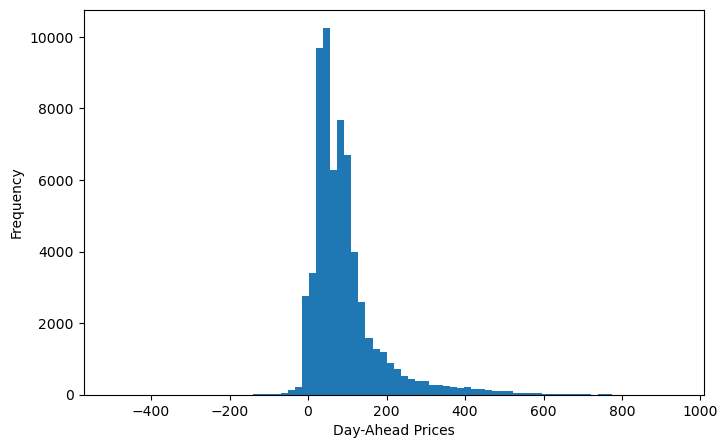

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["Price_DayAhead"], bins=80)
plt.xlabel("Day-Ahead Prices")
plt.ylabel("Frequency")
plt.show()

**Forecasted Demand** looks much more stable. The mean and median are close, and the interquartile range is narrow relative to the total range. This indicates a roughly symmetric distribution with predictable variability. The absence of extreme outliers suggests demand behaves smoothly compared to prices. \
\
**Solar production** is strongly right-skewed and zero-inflated. The 25th percentile is zero, while the median is very small relative to the mean, showing that a large fraction of hours have little or no solar output (nighttime).
**Wind offshore** and **Wind onshore** both show broad spreads. The mean exceeds the median in both cases, implying right-skewness, but unlike solar, the minimum values are strictly positive.\
\
**Weather temperature forecast** is relatively symmetric, with mean and median close and a bounded range that aligns with realistic Central European temperatures. This suggests a well-behaved, near-normal distribution, which makes it easier for models to learn from. **Solar and wind weather forecasts** imply similar behaviour as solar and wind production forecasts, which is exactly what we would want to expect.

## 2.2 Investigation of Relationships 


### Demand <-> Price 
Firstly, we will look at how the forecasted demand correlates with actual day-ahead electricity prices. 

In [11]:
from scipy import stats
spearman_corr, _ = stats.spearmanr(df['Load_Forecast'], df['Price_DayAhead'])
pearson_corr = df['Load_Forecast'].corr(df['Price_DayAhead'])
print(f"Pearson rank corr: {pearson_corr}")
print(f"Spearman rank corr: {spearman_corr}")

Pearson rank corr: 0.18280593390987035
Spearman rank corr: 0.20801308287938133


**Interpretation:** higher expected demand tends to coincide with higher prices, but demand alone explains only a limited part of price variation (weak correlation). Electricity prices correlate more with residual load, since demand on isolation does not imply much information (e.g. high demand with high renewables would not result in higher prices; moderate demand with low renewables could still result in high prices). Additionally, fuel prices, imports, bidding behavior add noise.

### (Demand & Renewables) <-> Price
Now, we will look at how the forecasted demand correlates with forecasted energy production from renewables using the formula for residual load. Residual load is the part of electricity demand that remains after subtracting variable renewable generation. The formula for hour *t* is
$$\text{Residual Load}_{t} = \text{Load}_{t} - \text{Wind}_{t} - \text{Solar}_{t}$$
High residual load means that renewables cower little of demand. Therefore, more conventional plants are needed, which results in higher electricity prices. It works the opposite way for low residual load, since in this case renewables cower most/all demand. \
\
This implies that residual load should strongly correlate with electricity prices. So, this is what we'll be testing next using **Spearman's rank** correlation. This correlation type is better suited for electricity price analysis because it captures monotonic but nonlinear relationships and is robust to extreme price spikes (e.g. sharp price spikes during scarcity events).

In [12]:
from scipy import stats
residual_load = df['Load_Forecast'] - df['Solar'] - df['Wind_Offshore'] - df['Wind_Onshore']
corr, _ = stats.spearmanr(df['Price_DayAhead'], residual_load)
print(f"Correlation between electricity prices and residual load: {corr}")

Correlation between electricity prices and residual load: 0.49619198966299793


**Interpretation:** The residual load shows a moderate to strong positive correlation with day-ahead prices. This indicates that higher residual load leads to higher day-ahead electricity. Even though substantial variability still remains due to unexplained market, fuel, and network effects, correlation rate of 0.49 motivates adding Residual Load as a model parameter.

### Demand <-> Weather

Next we will look at how forecasted weather correlates with forecasted demand. In this case we would expect the correlation index to be very low. This is because the relationship between these two variales is non-linear. Intuitively it is expected that cold weather leads to higher electricity prices (heating demand), as well as hot weather (cooling demand), while mild weather results in lower prices. So, it is better to investigate this relationship separately for hot and cold weather.

In [13]:
print(f"Demand to weather correlation: {df['Load_Forecast'].corr(df['Weather_Temp_Forecast'])}")
cold_temp = df.query('Weather_Temp_Forecast <= 0')['Weather_Temp_Forecast']
print(f"Demand to COLD weather correlation: {df['Load_Forecast'].corr(cold_temp)}")
hot_temp = df.query('Weather_Temp_Forecast >= 27')['Weather_Temp_Forecast']
print(f"Demand to HOT weather correlation: {df['Load_Forecast'].corr(hot_temp)}")

Demand to weather correlation: -0.09167546816005939
Demand to COLD weather correlation: -0.10855609621351851
Demand to HOT weather correlation: 0.1619999385893228


**Interpretation:** Even after calculating the correlation between two weather conditions separately, actual average temperature seem to significantly affect neither the expected demand or, therefore, the price.

### Renewables <-> Weather

Since residual load has a moderate to strong correlation with day-ahead prices, it is good to investigate the fact whether forecasted weather significantly impacts forecasted renewable energy production.

In [14]:
print(f"Solar production to shortwave radiation corr: {df['Solar'].corr(df['Weather_Solar_Forecast'])}")

df["Wind_Mean"] = df[["Wind_Offshore", "Wind_Onshore"]].mean(axis=1)
corr = df["Wind_Mean"].corr(df["Weather_Wind_Forecast"])
print(f"Mean wind production to wind speed corr: {corr}")

Solar production to shortwave radiation corr: 0.9361110653229873
Mean wind production to wind speed corr: 0.8270768743529014


**Interpretation:** Since the correlation is very strong in both cases, weather features, which we gathered, are meaningful and not random noise.

### Day Type <-> Price
Because electricity demand and market behavior differ systematically between weekdays, weekends, and public holidays, it is also important to investigate the relationship between day types and electricity prices. Weekdays typically exhibit higher industrial and commercial demand, leading to higher prices, while weekends and holidays show reduced activity and lower demand, often resulting in lower prices. These calendar effects are highly regular and cannot be fully captured by lagged prices or weather variables alone.

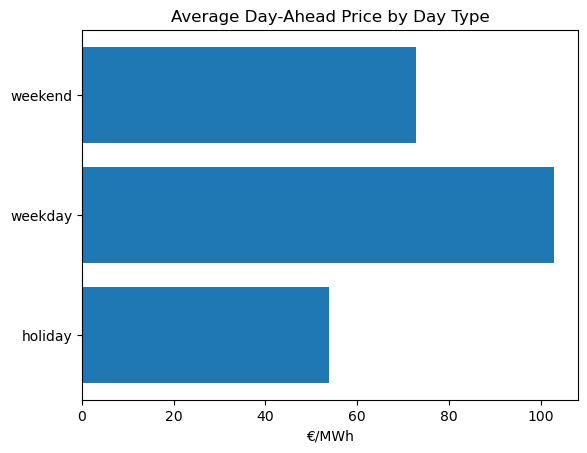

In [15]:
!pip install holidays
import holidays

# extract holidays for Germany for time period in our data set
years = range(df.index.year.min(), df.index.year.max() + 1)
de_holidays = holidays.Germany(years=years)

# assign day types
df['is_holiday'] = pd.Series(df.index.date, index=df.index).isin(de_holidays)
df['is_weekend'] = df.index.weekday >= 5
df['is_weekday'] = ~df['is_weekend']
df['day_type'] = 'weekday'
df.loc[df['is_weekend'], 'day_type'] = 'weekend'
df.loc[df['is_holiday'], 'day_type'] = 'holiday'

day_type_prices_avg = df.groupby('day_type')['Price_DayAhead'].mean().reset_index()

plt.figure()
plt.barh(day_type_prices_avg['day_type'], day_type_prices_avg['Price_DayAhead'])
plt.xlabel('€/MWh')
plt.title('Average Day-Ahead Price by Day Type')
plt.show()

**Interpretation:** the above mentioned expectations are confirmed.
* Weekdays: higher industrial and commercial demand -> higher prices
* Weekends: reduced economic activity -> lower demand -> lower prices
* Public holidays: demand often drops even further than on weekends

This motivates adding day type as a model parameter.

# Part 3. Modelling